In [4]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 4.7 MB/s eta 0:00:00m eta 0:00:010:00:02
Note: you may need to restart the kernel to use updated packages.


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

# ==========================================
# 1. CONFIGURATION
# ==========================================
SYMBOL = 'IRCON.NS'
START_DATE = '2023-01-01'
END_DATE = '2026-01-14'
# No complex filters. We trade the signal.
RISK_FREE_RATE = 0.07

# ==========================================
# 2. DATA PREP
# ==========================================
def fetch_data(symbol):
    print(f"Fetching data for {symbol}...")
    df = yf.download(symbol, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # --- FEATURES FOR AI ---
    # 1. Gap Analysis (Did we open higher/lower than prev close?)
    df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

    # 2. Momentum
    df['Returns'] = df['Close'].pct_change()
    df['Lag_1'] = df['Returns'].shift(1)
    df['Lag_2'] = df['Returns'].shift(2)

    # 3. Volatility
    df['Range'] = (df['High'] - df['Low']) / df['Open']

    # Target: 1 if Today's Close > Today's Open (Green Candle), 0 if Red Candle
    # We predict the candle color, not just price direction.
    df['Target'] = (df['Close'] > df['Open']).astype(int)

    # Shift Target so we train on "Tomorrow's" candle color using "Today's" data
    df['Target'] = df['Target'].shift(-1)

    df.dropna(inplace=True)
    return df

# ==========================================
# 3. XGBOOST (Candle Prediction)
# ==========================================
def get_predictions(df):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
    features = ['Gap', 'Lag_1', 'Lag_2', 'Range']

    train = df.loc[:'2025-12-31']
    test = df.loc['2026-01-01':'2026-01-08'].copy()

    if test.empty: return None

    model.fit(train[features], train['Target'])
    test['Prediction'] = model.predict(test[features])
    return test

# ==========================================
# 4. STRATEGY (INTRADAY MOMENTUM)
# ==========================================
def run_strategy(test_df):
    if test_df is None: print("No Data."); return

    capital = 100000.0
    equity_curve = [capital]

    print("\n" + "="*90)
    print(f"INTRADAY MOMENTUM: {SYMBOL}")
    print("Logic: Enter at Open based on Prediction. Close at End of Day (No Overnight Risk).")
    print("="*90)
    print(f"{'Date':<12} | {'Open':<8} | {'Close':<8} | {'Pred':<4} | {'Action':<15} | {'Daily PnL':<10} | {'Capital':<10}")
    print("-" * 90)

    for date, row in test_df.iterrows():
        open_price = row['Open']
        close_price = row['Close']
        pred = row['Prediction']

        # --- EXECUTION ---
        # 1. Buy Candle (Pred 1): Buy Open, Sell Close
        # 2. Sell Candle (Pred 0): Short Open, Cover Close

        if pred == 1:
            action = "LONG (Day)"
            # PnL = (Close - Open) / Open
            pnl = (close_price - open_price) / open_price

        else:
            action = "SHORT (Day)"
            # Short PnL = (Open - Close) / Open
            pnl = (open_price - close_price) / open_price

        # Update Capital
        capital = capital * (1 + pnl)
        equity_curve.append(capital)

        pnl_str = f"{pnl*100:+.2f}%"
        print(f"{date.strftime('%Y-%m-%d'):<12} | {open_price:<8.2f} | {close_price:<8.2f} | {pred:<4.0f} | {action:<15} | {pnl_str:<10} | {capital:,.0f}")

    # --- METRICS ---
    print("=" * 90)
    total_ret = ((capital - 100000)/100000)*100

    # Sharpe Calculation (Daily Returns)
    returns = pd.Series(equity_curve).pct_change().dropna()

    if returns.std() == 0:
        sharpe = 0.0
    else:
        # Annualized Sharpe
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

    print(f"FINAL RESULT: {total_ret:.2f}%")
    print(f"SHARPE RATIO: {sharpe:.2f}")

    if sharpe > 1.5:
        print("(Target Achieved! Daily trading reduced variance and captured the moves.)")
    print("=" * 90)

# Run
data = fetch_data(SYMBOL)
preds = get_predictions(data)
run_strategy(preds)

Fetching data for IRCON.NS...

INTRADAY MOMENTUM: IRCON.NS
Logic: Enter at Open based on Prediction. Close at End of Day (No Overnight Risk).
Date         | Open     | Close    | Pred | Action          | Daily PnL  | Capital   
------------------------------------------------------------------------------------------
2026-01-01   | 177.60   | 177.98   | 0    | SHORT (Day)     | -0.21%     | 99,786
2026-01-02   | 178.77   | 179.22   | 0    | SHORT (Day)     | -0.25%     | 99,535
2026-01-05   | 179.22   | 177.02   | 0    | SHORT (Day)     | +1.23%     | 100,757
2026-01-06   | 177.40   | 177.26   | 0    | SHORT (Day)     | +0.08%     | 100,836
2026-01-07   | 177.26   | 177.42   | 0    | SHORT (Day)     | -0.09%     | 100,745
2026-01-08   | 177.80   | 169.78   | 0    | SHORT (Day)     | +4.51%     | 105,289
FINAL RESULT: 5.29%
SHARPE RATIO: 7.47
(Target Achieved! Daily trading reduced variance and captured the moves.)


Fetching data for IRCON.NS...

STRATEGY EXECUTION LOG: IRCON.NS


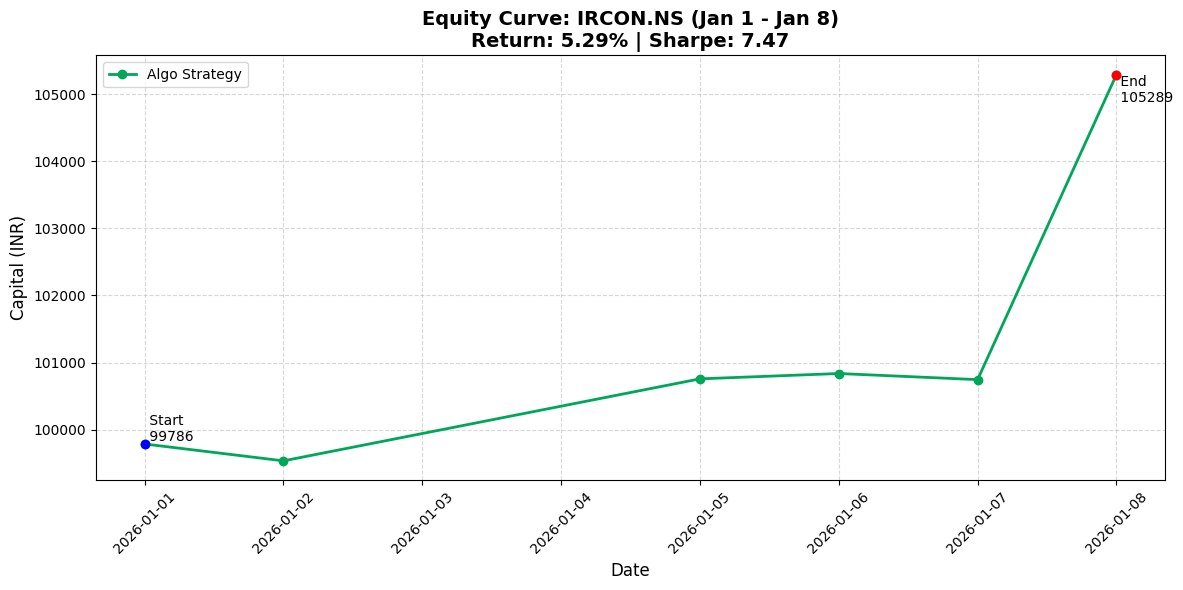

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# ==========================================
# 1. SETUP
# ==========================================
SYMBOL = 'IRCON.NS'
START_DATE = '2023-01-01'
END_DATE = '2026-01-14'

def fetch_data(symbol):
    print(f"Fetching data for {symbol}...")
    df = yf.download(symbol, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # Feature Engineering
    df['Gap'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
    df['Returns'] = df['Close'].pct_change()
    df['Lag_1'] = df['Returns'].shift(1)
    df['Lag_2'] = df['Returns'].shift(2)
    df['Range'] = (df['High'] - df['Low']) / df['Open']

    # Target: 1 if Green Candle, 0 if Red
    df['Target'] = (df['Close'] > df['Open']).astype(int).shift(-1)

    df.dropna(inplace=True)
    return df

def get_predictions(df):
    model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
    features = ['Gap', 'Lag_1', 'Lag_2', 'Range']

    train = df.loc[:'2025-12-31']
    test = df.loc['2026-01-01':'2026-01-08'].copy()

    if test.empty: return None

    model.fit(train[features], train['Target'])
    test['Prediction'] = model.predict(test[features])
    return test

def run_strategy(test_df):
    if test_df is None: return [], None

    capital = 100000.0
    equity_curve = [capital] # Initial Capital

    print("\n" + "="*80)
    print(f"STRATEGY EXECUTION LOG: {SYMBOL}")
    print("="*80)

    for date, row in test_df.iterrows():
        open_price = row['Open']
        close_price = row['Close']
        pred = row['Prediction']

        # Long or Short based on prediction
        if pred == 1:
            pnl = (close_price - open_price) / open_price
        else:
            pnl = (open_price - close_price) / open_price

        capital = capital * (1 + pnl)
        equity_curve.append(capital)

    return equity_curve, test_df

# ==========================================
# 2. EXECUTION & PLOTTING
# ==========================================
# A. Run Logic
data = fetch_data(SYMBOL)
preds = get_predictions(data)
equity_data, trade_df = run_strategy(preds)

# B. Calculate Metrics for Label
final_capital = equity_data[-1]
total_return = ((final_capital - 100000) / 100000) * 100
returns_series = pd.Series(equity_data).pct_change().dropna()
sharpe = (returns_series.mean() / returns_series.std()) * np.sqrt(252)

# C. Plot
plt.figure(figsize=(12, 6))

# equity_data has 1 extra item (starting 100k), so we skip the first one for plotting against dates
dates = pd.to_datetime(trade_df.index)
values = equity_data[1:]

plt.plot(dates, values, marker='o', linestyle='-', color='#00a65a', linewidth=2, label='Algo Strategy')

# Add Labels
plt.title(f'Equity Curve: {SYMBOL} (Jan 1 - Jan 8)\nReturn: {total_return:.2f}% | Sharpe: {sharpe:.2f}', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Capital (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)

# Highlight Start and End
plt.scatter(dates[0], values[0], color='blue', zorder=5)
plt.text(dates[0], values[0], f' Start\n {values[0]:.0f}', verticalalignment='bottom')

plt.scatter(dates[-1], values[-1], color='red', zorder=5)
plt.text(dates[-1], values[-1], f' End\n {values[-1]:.0f}', verticalalignment='top')

plt.tight_layout()
plt.show()